# Correlated observations

Two datasets that are each internally independent but share a calibration
are *correlated observations*: fitting them as if independent is
overconfident, because the common mode cannot average down.  In `rxmc` the
coupling is one covariance term whose support spans both comparisons.  The
second half recreates the two-and-more-dimensional Peelle's Pertinent Puzzle
of Neudecker, Frühwirth, Kawano and Leeb, *Nucl. Data Sheets* **118**, 364
(2014): several physical quantities of one experiment with correlated
normalisations, and why the covariance must be built from the estimate and
not from the data.

Recipes: 5, 37

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import rxmc as rx
from rxmc import terms as T

## Two datasets with a shared calibration

One line, two experiments on disjoint ranges, one calibration factor drawn
once and applied to both.  Each experiment reports its own 2 % statistics and
a 10 % normalisation uncertainty, without saying that it is the *same*
normalisation.

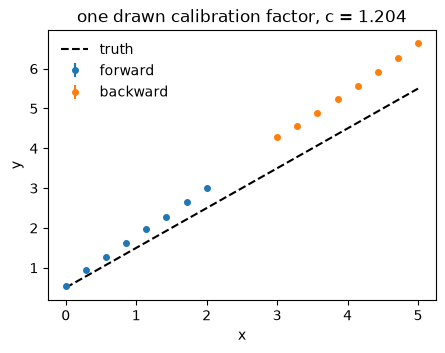

In [2]:
rng = np.random.default_rng(3)
m_true, b_true = 1.0, 0.5
sigma_c, noise = 0.10, 0.02
c_factor = rng.normal(1.0, sigma_c)
x1, x2 = np.linspace(0.0, 2.0, 8), np.linspace(3.0, 5.0, 8)
y1 = c_factor * (m_true * x1 + b_true) + rng.normal(0.0, noise, 8)
y2 = c_factor * (m_true * x2 + b_true) + rng.normal(0.0, noise, 8)
d1 = rx.Dataset(x1, y1, np.full(8, noise), norm_err=sigma_c, label="forward")
d2 = rx.Dataset(x2, y2, np.full(8, noise), norm_err=sigma_c, label="backward")

fig, ax = plt.subplots(figsize=(5, 3.5))
for d in (d1, d2):
    ax.errorbar(d.x, d.y, d.y_err, fmt="o", ms=4, label=d.label)
x_line = np.linspace(0, 5, 2)
ax.plot(x_line, m_true * x_line + b_true, "k--", label="truth")
ax.set(
    xlabel="x", ylabel="y", title=f"one drawn calibration factor, c = {c_factor:.3f}"
)
ax.legend(frameon=False)
plt.show()

## The covariance structure: coupled or independent

The same 10 % normalisation, spelled two ways.  With `on=[comp1, comp2]` a
single mode spans both blocks and writes off-diagonal blocks into Σ.  With
one term per comparison the blocks are independent.  Both are built from the
prediction, never from the data.

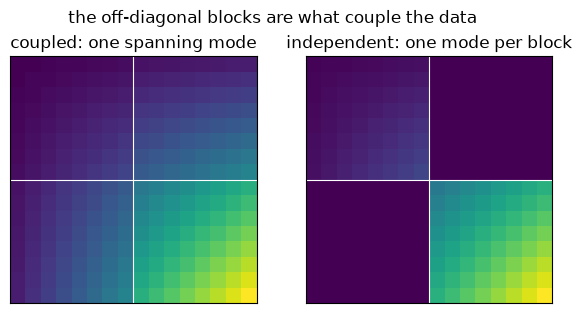

In [3]:
m = rx.Parameter("m", prior=stats.norm(1.0, 0.3), latex="m")
b = rx.Parameter("b", prior=stats.norm(0.5, 0.3), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
comp1, comp2 = rx.Comparison(d1, line), rx.Comparison(d2, line)

c_coupled = rx.Constraint(
    [comp1, comp2], terms=[T.normalization(magnitude=sigma_c, on=[comp1, comp2])]
)
c_indep = rx.Constraint(
    [comp1, comp2],
    terms=[
        T.normalization(magnitude=sigma_c, on=comp1),
        T.normalization(magnitude=sigma_c, on=comp2),
    ],
)
p_coupled, p_indep = rx.Problem([c_coupled]), rx.Problem([c_indep])
theta_true = np.array([m_true, b_true])

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
for ax, p, title in zip(
    axes,
    (p_coupled, p_indep),
    ("coupled: one spanning mode", "independent: one mode per block"),
):
    S = p.constraints[0].matrix(theta_true)
    im = ax.imshow(S, cmap="viridis")
    ax.axhline(7.5, color="w", lw=0.8)
    ax.axvline(7.5, color="w", lw=0.8)
    ax.set(title=title, xticks=[], yticks=[])
fig.suptitle("the off-diagonal blocks are what couple the data")
plt.show()

## Effect on inference

Same data, same model, same magnitudes: the coupled fit is appropriately
less certain, the independent one is overconfident.  Both are honest about
their statistics; only one is honest about the calibration.

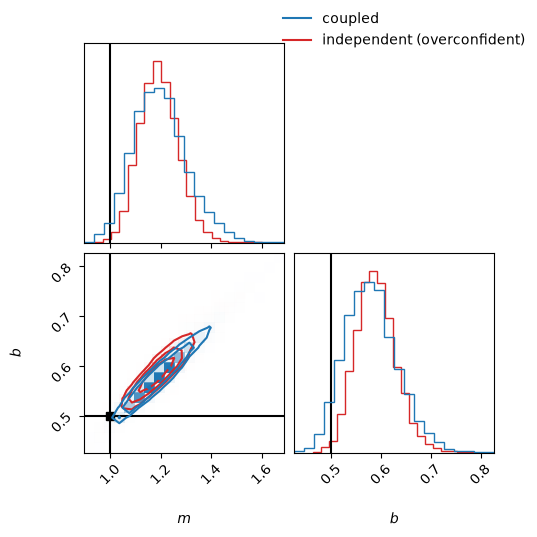

coupled      m = 1.199 +/- 0.107   b = 0.581 +/- 0.053
independent  m = 1.193 +/- 0.078   b = 0.589 +/- 0.041


In [4]:
def fit(problem, seed, n_walkers=24, n_steps=1800):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


s_coupled, s_indep = fit(p_coupled, seed=1), fit(p_indep, seed=2)
fig = corner.corner(
    s_indep,
    color="C3",
    labels=["$m$", "$b$"],
    truths=theta_true,
    truth_color="k",
    plot_datapoints=False,
)
corner.corner(s_coupled, fig=fig, color="C0", plot_datapoints=False)
fig.legend(
    handles=[
        plt.Line2D([], [], color="C0", label="coupled"),
        plt.Line2D([], [], color="C3", label="independent (overconfident)"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()
for name, s in (("coupled", s_coupled), ("independent", s_indep)):
    print(
        f"{name:12s} m = {s[:, 0].mean():.3f} +/- {s[:, 0].std():.3f}   b = {s[:, 1].mean():.3f} +/- {s[:, 1].std():.3f}"
    )

## Case A and case B with a *free* shared nuisance

If the magnitude of the shared calibration is unknown, one `Parameter`
object carries it.  Where you put the object decides the structure:

- **case A couples the data**: one term `on=[comp1, comp2]` reads the
  object once, and Σ has off-diagonal blocks;
- **case B couples the parameters**: two terms, one per comparison, both
  reading the same object; Σ stays block diagonal but the two blocks scale
  together.

Both have exactly one nuisance column, because parameters are matched by
identity, not by name.

In [5]:
log_eta = rx.Parameter("log_eta", prior=stats.norm(np.log(0.1), 1.0), latex=r"\log\eta")
c_A = rx.Constraint([comp1, comp2], terms=[T.normalization(log_eta, on=[comp1, comp2])])
c_B = rx.Constraint(
    [comp1, comp2],
    terms=[T.normalization(log_eta, on=comp1), T.normalization(log_eta, on=comp2)],
)
for name, c in (("case A", c_A), ("case B", c_B)):
    p = rx.Problem([c])
    S = p.constraints[0].matrix(np.array([m_true, b_true, np.log(0.1)]))
    print(
        f"{name}: columns {p.names}, max |off-diagonal block| = {np.abs(S[:8, 8:]).max():.2e}"
    )

case A: columns ['m', 'b', 'log_eta'], max |off-diagonal block| = 1.38e-01
case B: columns ['m', 'b', 'log_eta'], max |off-diagonal block| = 0.00e+00


## More than one physical quantity: Neudecker et al. (2014)

The reference studies an experiment that reports several physical
quantities `ρ_i = α_i η_i`.  Each `α_i` is measured as `q_i`, once or more,
with independent errors `σ_i`; each normalisation `η_i` is measured as
`N_i`, and the `N_i` share a covariance `B` with correlation `c`.  The
reported data are the products `r_i = q_i N_i`, and the question is how to
build their covariance.

- **`C_F`** (their eq. 11) propagates the normalisation error with the
  *measured* `q`: the mode of quantity `i` is `σ_N,i q_i`.
- **`C_I`** (their eq. 12) uses the *estimate*, the weighted mean `q̄_i`:
  the mode is `σ_N,i q̄_i`, which in `rxmc` is the prediction divided by
  `N_i`, i.e. the term reads `c.ym`.

With `C_F` the evaluation is biased low and too narrow: Peelle's Pertinent
Puzzle, now across quantities.  Here is the model: one comparison per
quantity, the quantity itself as the model, and one `matrix` term spanning
all comparisons that pairs `c.split(c.ym)` with the correlation matrix of the
normalisations.

In [6]:
def experiment(q, N, sigma_q, sigma_N, prior=stats.uniform(0.0, 10.0)):
    comps, rhos = [], []
    for i, (qi, Ni, si) in enumerate(zip(q, N, sigma_q)):
        rho = rx.Parameter(f"rho_{i + 1}", prior=prior, latex=rf"\rho_{i + 1}")
        rhos.append(rho)
        d = rx.Dataset(
            np.full(len(qi), i),
            np.asarray(qi) * Ni,
            Ni * np.asarray(si),
            label=f"quantity {i + 1}",
        )
        comps.append(rx.Comparison(d, rx.Model(lambda x, r: np.full(len(x), r), [rho])))
    return comps, rhos


def normalisations(comps, frac, corr, from_data=False):
    """outer(f * ym, f * ym) * corr across the quantities; from y for C_F."""
    corr = np.asarray(corr, dtype=float)

    def fn(c):
        pieces = c.split(c.y if from_data else c.ym)
        u = np.concatenate([f * piece for f, piece in zip(frac, pieces)])
        which = np.concatenate(
            [np.full(s.stop - s.start, k) for k, s in enumerate(c.segments)]
        )
        return np.outer(u, u) * corr[np.ix_(which, which)]

    return rx.Term(fn, kind="matrix", on=comps, constant=from_data)


def fixed_estimate(comps, rho, frac, corr, counts):
    """C_I in its fixed form: the mode built from an estimate of each rho."""
    u = np.concatenate([np.full(n, f * r) for n, f, r in zip(counts, frac, rho)])
    which = np.concatenate([np.full(n, k) for k, n in enumerate(counts)])
    return rx.Term(
        np.outer(u, u) * np.asarray(corr)[np.ix_(which, which)], kind="matrix", on=comps
    )


def exact(q, N, sigma_q, sigma_N, corr):
    """Means and covariance from the full information (their eqs. 2-8)."""
    w = [1.0 / np.asarray(s) ** 2 for s in sigma_q]
    qbar = np.array([np.sum(wi * qi) / np.sum(wi) for wi, qi in zip(w, q)])
    var_a = np.array([1.0 / np.sum(wi) for wi in w])
    N, sN = np.asarray(N), np.asarray(sigma_N)
    cov = np.outer(qbar * sN, qbar * sN) * np.asarray(corr)
    cov[np.diag_indices_from(cov)] += var_a * N**2
    return qbar * N, cov, qbar


def gls(problem, theta_any):
    """Posterior mean and covariance under a *fixed* covariance and a flat prior."""
    c = problem.constraints[0]
    S = c.matrix(theta_any)
    X = np.eye(problem.ndim)[c.x[c.active].astype(int)]
    cov = np.linalg.inv(X.T @ np.linalg.solve(S, X))
    return cov @ (X.T @ np.linalg.solve(S, c.y[c.active])), cov

### II.A: the analytic study

Quantity 1 measured twice, quantity 2 once, 10 % statistics, 20 %
normalisations correlated at `c = 0.8`.  The reference's closed forms:
under `C_F`, `⟨ρ_1⟩ = q̄_1 N_1 / (1 + ξ)` with
`ξ = (q_1 − q_1')² σ²_N1 var(α_1) / (N_1² σ_1² σ_1'²)`, and `⟨ρ_2⟩` is pulled
down through `c` although `α_2` was measured once; under `C_I` the means are
`q̄_i N_i` exactly.

In [7]:
q = [np.array([1.0, 1.5]), np.array([1.8])]
N = np.array([1.0, 1.1])
sigma_q = [0.1 * qi for qi in q]
sigma_N = 0.2 * N
c_corr = 0.8
corr = np.array([[1.0, c_corr], [c_corr, 1.0]])
counts = [len(qi) for qi in q]

comps, rhos = experiment(q, N, sigma_q, sigma_N)
mean, cov, qbar = exact(q, N, sigma_q, sigma_N, corr)
p_F = rx.Problem(
    [
        rx.Constraint(
            comps, terms=[normalisations(comps, sigma_N / N, corr, from_data=True)]
        )
    ]
)
p_I = rx.Problem(
    [
        rx.Constraint(
            comps, terms=[fixed_estimate(comps, mean, sigma_N / N, corr, counts)]
        )
    ]
)
mean_F, cov_F = gls(p_F, mean)
mean_I, cov_I = gls(p_I, mean)

var_a1 = 1.0 / np.sum(1.0 / sigma_q[0] ** 2)
xi = (
    (q[0][0] - q[0][1]) ** 2
    * sigma_N[0] ** 2
    * var_a1
    / (N[0] ** 2 * sigma_q[0][0] ** 2 * sigma_q[0][1] ** 2)
)
print(f"xi = {xi:.4f}")
print(f"exact       : rho = {mean.round(4)}   sd = {np.sqrt(np.diag(cov)).round(4)}")
print(
    f"C_I (est.)  : rho = {mean_I.round(4)}   sd = {np.sqrt(np.diag(cov_I)).round(4)}"
)
print(
    f"C_F (data)  : rho = {mean_F.round(4)}   sd = {np.sqrt(np.diag(cov_F)).round(4)}"
)
print(f"eq. 13      : rho_1 = {qbar[0] * N[0] / (1 + xi):.4f}")

xi = 0.3077
exact       : rho = [1.1538 1.98  ]   sd = [0.2453 0.4427]
C_I (est.)  : rho = [1.1538 1.98  ]   sd = [0.2453 0.4427]
C_F (data)  : rho = [0.8824 1.6073]   sd = [0.2183 0.4152]
eq. 13      : rho_1 = 0.8824


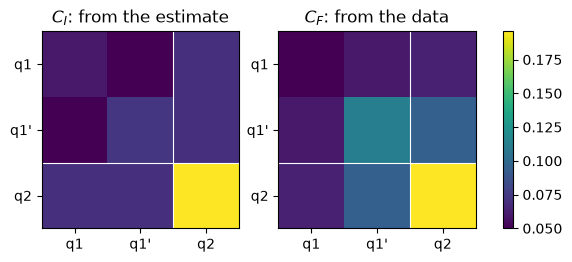

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
for ax, p, title in zip(
    axes, (p_I, p_F), (r"$C_I$: from the estimate", r"$C_F$: from the data")
):
    im = ax.imshow(p.constraints[0].matrix(mean), cmap="viridis")
    ax.axhline(1.5, color="w", lw=0.8)
    ax.axvline(1.5, color="w", lw=0.8)
    ax.set(
        title=title,
        xticks=range(3),
        yticks=range(3),
        xticklabels=["q1", "q1'", "q2"],
        yticklabels=["q1", "q1'", "q2"],
    )
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

### II.B: the five-quantity numerical study

Table I of the reference: five quantities, most measured twice, `σ_i = 0.1
q_i`, `σ_N,i = 0.2 N_i`, `c = 0.8`.  Its Fig. 1 compares the means and
standard deviations of the `ρ_i` from the full information with those from
`C_I` and `C_F`.  Both posteriors are Gaussian (fixed covariance, flat
prior), so emcee is only a check on the closed form here; the figure is the
point.

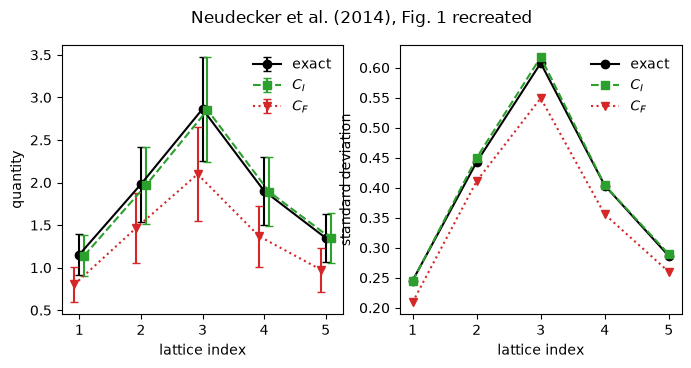

In [9]:
q5 = [
    np.array([1.0, 1.5]),
    np.array([1.8]),
    np.array([2.2, 2.4]),
    np.array([1.9, 1.5]),
    np.array([1.4, 1.2]),
]
N5 = np.array([1.0, 1.1, 1.25, 1.15, 1.05])
sigma_q5 = [0.1 * qi for qi in q5]
sigma_N5 = 0.2 * N5
corr5 = np.full((5, 5), c_corr) + (1 - c_corr) * np.eye(5)
counts5 = [len(qi) for qi in q5]

comps5, rhos5 = experiment(q5, N5, sigma_q5, sigma_N5)
mean5, cov5, qbar5 = exact(q5, N5, sigma_q5, sigma_N5, corr5)
p5_F = rx.Problem(
    [
        rx.Constraint(
            comps5, terms=[normalisations(comps5, sigma_N5 / N5, corr5, from_data=True)]
        )
    ]
)
p5_I = rx.Problem(
    [
        rx.Constraint(
            comps5, terms=[fixed_estimate(comps5, mean5, sigma_N5 / N5, corr5, counts5)]
        )
    ]
)
s5_F, s5_I = fit(p5_F, seed=5, n_steps=3000), fit(p5_I, seed=6, n_steps=3000)

lattice = np.arange(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].errorbar(
    lattice, mean5, np.sqrt(np.diag(cov5)), fmt="ko-", capsize=3, label="exact"
)
axes[0].errorbar(
    lattice + 0.08,
    s5_I.mean(0),
    s5_I.std(0),
    fmt="s--",
    color="C2",
    capsize=3,
    label=r"$C_I$",
)
axes[0].errorbar(
    lattice - 0.08,
    s5_F.mean(0),
    s5_F.std(0),
    fmt="v:",
    color="C3",
    capsize=3,
    label=r"$C_F$",
)
axes[0].set(xlabel="lattice index", ylabel="quantity", xticks=lattice)
axes[0].legend(frameon=False)
axes[1].plot(lattice, np.sqrt(np.diag(cov5)), "ko-", label="exact")
axes[1].plot(lattice, s5_I.std(0), "s--", color="C2", label=r"$C_I$")
axes[1].plot(lattice, s5_F.std(0), "v:", color="C3", label=r"$C_F$")
axes[1].set(xlabel="lattice index", ylabel="standard deviation", xticks=lattice)
axes[1].legend(frameon=False)
fig.suptitle("Neudecker et al. (2014), Fig. 1 recreated")
plt.show()

`C_I` reproduces the exact means and widths; `C_F` is below them on every
lattice point, in both the mean and the width.  The reference's real-data
case has the same structure: ²³⁷Np(n,f) measured by three experiments as
ratios to the ²³⁵U(n,f) standard, converted with the standard's covariance
as `B`, where `C_F` lowers the evaluated cross sections below every dataset.

### The live term and the log-determinant

`rxmc`'s `T.normalization` and the spanning term above read `c.ym`, so the
covariance moves with the parameters: this is the generative model's
marginal likelihood, not the fixed `C_I`.  A covariance that grows with the
prediction pulls the posterior mode down through `log det Σ`; with 20 %
normalisations it is a 9 % pull here, against 27 to 31 % for `C_F`.  A proper
prior on the quantities, or the two-step refit (`C_I` built from a first
estimate, as above), removes it.

In [10]:
from scipy.optimize import minimize

p5_live = rx.Problem(
    [rx.Constraint(comps5, terms=[normalisations(comps5, sigma_N5 / N5, corr5)])]
)
mode = minimize(lambda t: -p5_live.log_posterior(t), mean5, method="Nelder-Mead").x
print("relative pull of the mode, live term:", np.round(mode / mean5 - 1, 3))
print(
    "relative bias of the mean, C_F      :",
    np.round(gls(p5_F, mean5)[0] / mean5 - 1, 3),
)

relative pull of the mode, live term: [-0.09 -0.09 -0.09 -0.09 -0.09]
relative bias of the mean, C_F      : [-0.311 -0.268 -0.271 -0.284 -0.275]


## Takeaways

- Correlated observations are one covariance term whose support spans the
  comparisons; no special machinery.
- Fitting shared-systematic datasets independently is overconfident.  Case A
  couples the data, case B couples the parameters; both are declared by
  where a term sits and which `Parameter` object it reads.
- Across several physical quantities the correlated normalisations are one
  spanning `matrix` term paired with the normalisation correlation matrix,
  read per quantity through `c.split`.
- Build the modes from the estimate, never from the data: that is the
  whole of Peelle's Pertinent Puzzle in any number of dimensions.